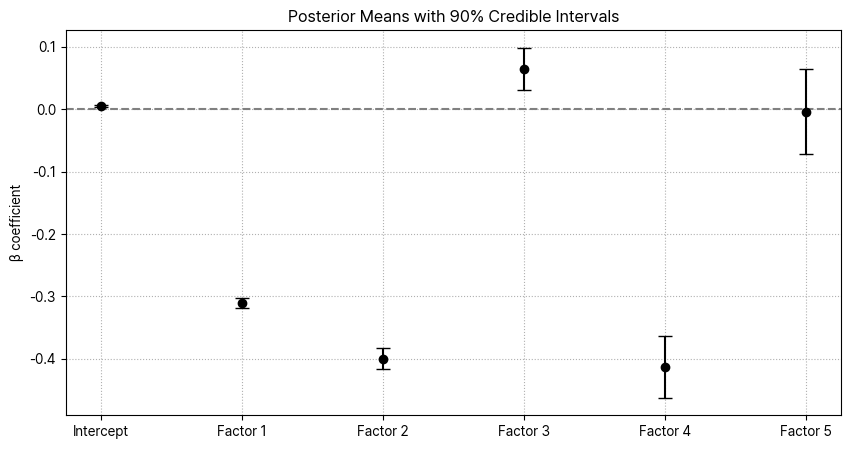

In [1]:
import matplotlib.pyplot as plt

# 요인 이름
factors = ['Intercept', 'Factor 1', 'Factor 2', 'Factor 3', 'Factor 4', 'Factor 5']

# Posterior mean
means = [0.0048, -0.3108, -0.3997, 0.0648, -0.4132, -0.0042]

# 95% 신뢰구간 (b_0.05, b_0.95)
lower = [0.0029, -0.3187, -0.4168, 0.0312, -0.4624, -0.0721]
upper = [0.0067, -0.3029, -0.3827, 0.0983, -0.3640, 0.0636]

# 플롯
plt.figure(figsize=(10, 5))
plt.errorbar(factors, means, yerr=[ [m - l for m, l in zip(means, lower)],
                                    [u - m for u, m in zip(upper, means)] ],
             fmt='o', capsize=5, color='black')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Posterior Means with 90% Credible Intervals')
plt.ylabel('β coefficient')
plt.grid(True, linestyle=':')
plt.show()

[*********************100%***********************]  1 of 1 completed


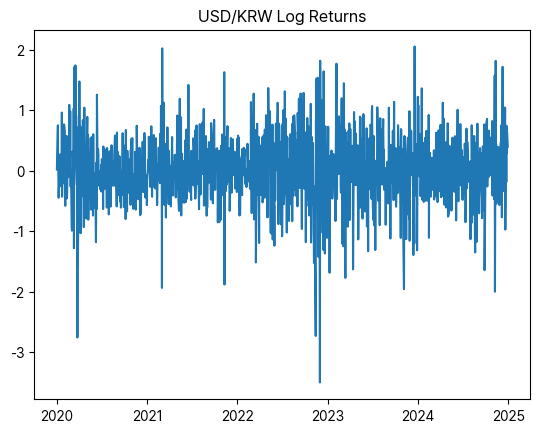

In [6]:
import pymc as pm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# USD/KRW 환율 데이터 다운로드
data = yf.download("KRW=X", start="2020-01-01", end="2024-12-31", auto_adjust=False)["Adj Close"]
log_returns = 100 * np.log(data / data.shift(1)).dropna()  # 로그 수익률 (%)

plt.plot(log_returns)
plt.title("USD/KRW Log Returns")
plt.show()

In [14]:
import pymc as pm
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# 데이터 준비
data = yf.download("KRW=X", start="2024-03-01", auto_adjust=False)["Adj Close"]
log_returns = 100 * np.log(data / data.shift(1)).dropna()
T = len(log_returns)

with pm.Model() as ar_model:
    # rho를 AR(1)로 정의 (벡터로!)
    mu = pm.Normal("mu", mu=0, sigma=1)  # 평균 수익률
    rho = pm.Normal("rho", mu=0, sigma=1, shape=1)
    sigma = pm.Exponential("sigma", 1.0)

    # AR(1) 프로세스 정의
    h = pm.AR("h", rho=rho, sigma=sigma, shape=len(log_returns))

    # 관측 수익률과 연결
    y = pm.Normal("y", mu=mu, sigma=pm.math.exp(h / 2), observed=log_returns.values)

    trace = pm.sample(2000, target_accept=0.99, return_inferencedata=True)

[*********************100%***********************]  1 of 1 completed
/opt/conda/envs/bap3/lib/python3.11/site-packages/pymc/distributions/timeseries.py:558: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100, shape=...)`. You can specify an init_dist manually to suppress this warning.
  warnings.warn(
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, rho, sigma, h]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2986 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


In [16]:
import arviz as az

az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,0.012,0.002,0.008,0.016,0.0,0.0,9633.0,5676.0,1.00
rho[0],1.000,0.000,1.000,1.000,0.0,0.0,1047.0,942.0,1.01
h[0],-0.974,0.011,-0.996,-0.954,0.0,0.0,606.0,1272.0,1.01
h[1],-0.974,0.011,-0.996,-0.954,0.0,0.0,591.0,1159.0,1.01
h[2],-0.974,0.011,-0.995,-0.954,0.0,0.0,579.0,1248.0,1.01
...,...,...,...,...,...,...,...,...,...
h[300],-0.974,0.010,-0.993,-0.955,0.0,0.0,665.0,1388.0,1.01
h[301],-0.974,0.010,-0.994,-0.955,0.0,0.0,663.0,1421.0,1.01
h[302],-0.974,0.010,-0.993,-0.954,0.0,0.0,667.0,1445.0,1.01
h[303],-0.974,0.011,-0.994,-0.954,0.0,0.0,673.0,1514.0,1.01
